In [1]:
import decoupler as dc
import liana as li
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import session_info

import cellphonedb
from liana.method import cellphonedb
# Name: cellphonedb
# Version: 5.0.1

# import anndata2ri
# anndata2ri.activate()
# %load_ext rpy2.ipython

In [2]:
# figure settings
sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200, facecolor="white")
sc.set_figure_params(figsize=(5, 5))

/tmp/ipykernel_70033/2857476846.py:2: FutureWarning: Use `scanpy.set_figure_params` instead


In [3]:
import os 
print(os.getcwd())

/home/tanasa/Desktop/LIANA


In [4]:
import os

# current directory
print(os.listdir())

# or sorted
print(sorted(os.listdir()))

# with full path
import glob
print(glob.glob("*"))

# only h5ad files
print(glob.glob("*.h5ad"))

# current directory path
print(os.getcwd())

['liana_env_clean', 'LIANA-tutorial.IFNG.stim.ipynb', 'LIANA-tutorial.v2.ipynb', 'dotplot_combined.png', 'seurat5_integrated_RPCA.rds', 'kang.h5ad', 'seurat5_integrated_CCA.rds', 'liana_env', 'omnipathr-log', 'seurat5_integrated_Harmony.rds', '.ipynb_checkpoints', 'dotplot_combined.pdf', 'LIANA-tutorial.v1.ipynb', 'LGG_LIANA.ipynb']
['.ipynb_checkpoints', 'LGG_LIANA.ipynb', 'LIANA-tutorial.IFNG.stim.ipynb', 'LIANA-tutorial.v1.ipynb', 'LIANA-tutorial.v2.ipynb', 'dotplot_combined.pdf', 'dotplot_combined.png', 'kang.h5ad', 'liana_env', 'liana_env_clean', 'omnipathr-log', 'seurat5_integrated_CCA.rds', 'seurat5_integrated_Harmony.rds', 'seurat5_integrated_RPCA.rds']
['liana_env_clean', 'LIANA-tutorial.IFNG.stim.ipynb', 'LIANA-tutorial.v2.ipynb', 'dotplot_combined.png', 'seurat5_integrated_RPCA.rds', 'kang.h5ad', 'seurat5_integrated_CCA.rds', 'liana_env', 'omnipathr-log', 'seurat5_integrated_Harmony.rds', 'dotplot_combined.pdf', 'LIANA-tutorial.v1.ipynb', 'LGG_LIANA.ipynb']
['kang.h5ad']
/ho

In [5]:
# https://www.sc-best-practices.org/mechanisms/cell_cell_communication.html

In [6]:
# Read in
adata = sc.read("kang.h5ad")

# ── Full structure overview ───────────────────────────────────
print(adata)

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name'
    obsm: 'X_pca', 'X_umap'


In [7]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [8]:
print(adata.X[1:5, 1:5].toarray())

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [9]:
# Store the counts for later use
adata.layers["counts"] = adata.X.copy()

# Rename label to condition, replicate to patient
adata.obs = adata.obs.rename({"label": "condition", "replicate": "patient"}, axis=1)

# assign sample
adata.obs["sample"] = (
    adata.obs["condition"].astype("str") + "&" + adata.obs["patient"].astype("str")
)

In [10]:
print(adata.obs.head(5))

                  nCount_RNA  nFeature_RNA      tsne1      tsne2 condition  \
index                                                                        
AAACATACATTTCC-1      3017.0           877 -27.640373  14.966629      ctrl   
AAACATACCAGAAA-1      2481.0           713 -27.493646  28.924885      ctrl   
AAACATACCATGCA-1       703.0           337 -10.468194  -5.984389      ctrl   
AAACATACCTCGCT-1      3420.0           850 -24.367997  20.429285      ctrl   
AAACATACCTGGTA-1      3158.0          1111  27.952170  24.159738      ctrl   

                  cluster        cell_type       patient  nCount_SCT  \
index                                                                  
AAACATACATTTCC-1        9  CD14+ Monocytes  patient_1016      1704.0   
AAACATACCAGAAA-1        9  CD14+ Monocytes  patient_1256      1614.0   
AAACATACCATGCA-1        3      CD4 T cells  patient_1488       908.0   
AAACATACCTCGCT-1        9  CD14+ Monocytes  patient_1256      1738.0   
AAACATACCTGGTA-1     

In [11]:
print(adata.var.head(5))

                        name  n_cells
index                                
AL627309.1        AL627309.1        6
RP11-206L10.2  RP11-206L10.2        6
RP11-206L10.9  RP11-206L10.9        7
FAM87B                FAM87B        4
LINC00115          LINC00115       90


In [12]:
print(adata.obs["condition"].unique())
print(adata.obs["cell_type"].unique())

# with counts
print(adata.obs["condition"].value_counts())
print(adata.obs["cell_type"].value_counts())

['ctrl', 'stim']
Categories (2, object): ['ctrl', 'stim']
['CD14+ Monocytes', 'CD4 T cells', 'Dendritic cells', 'NK cells', 'CD8 T cells', 'B cells', 'FCGR3A+ Monocytes', 'Megakaryocytes']
Categories (8, object): ['CD4 T cells', 'CD14+ Monocytes', 'B cells', 'NK cells', 'CD8 T cells', 'FCGR3A+ Monocytes', 'Dendritic cells', 'Megakaryocytes']
condition
stim    12301
ctrl    12261
Name: count, dtype: int64
cell_type
CD4 T cells          11238
CD14+ Monocytes       5696
B cells               2651
NK cells              1716
CD8 T cells           1621
FCGR3A+ Monocytes     1089
Dendritic cells        529
Megakaryocytes          22
Name: count, dtype: int64


In [13]:
# all columns at once
# for col in adata.obs.columns:
#    n = adata.obs[col].nunique()
#    print(f"{col}: {n} unique values → {adata.obs[col].unique().tolist()}")

In [14]:
# log1p normalize the data
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

... storing 'sample' as categorical


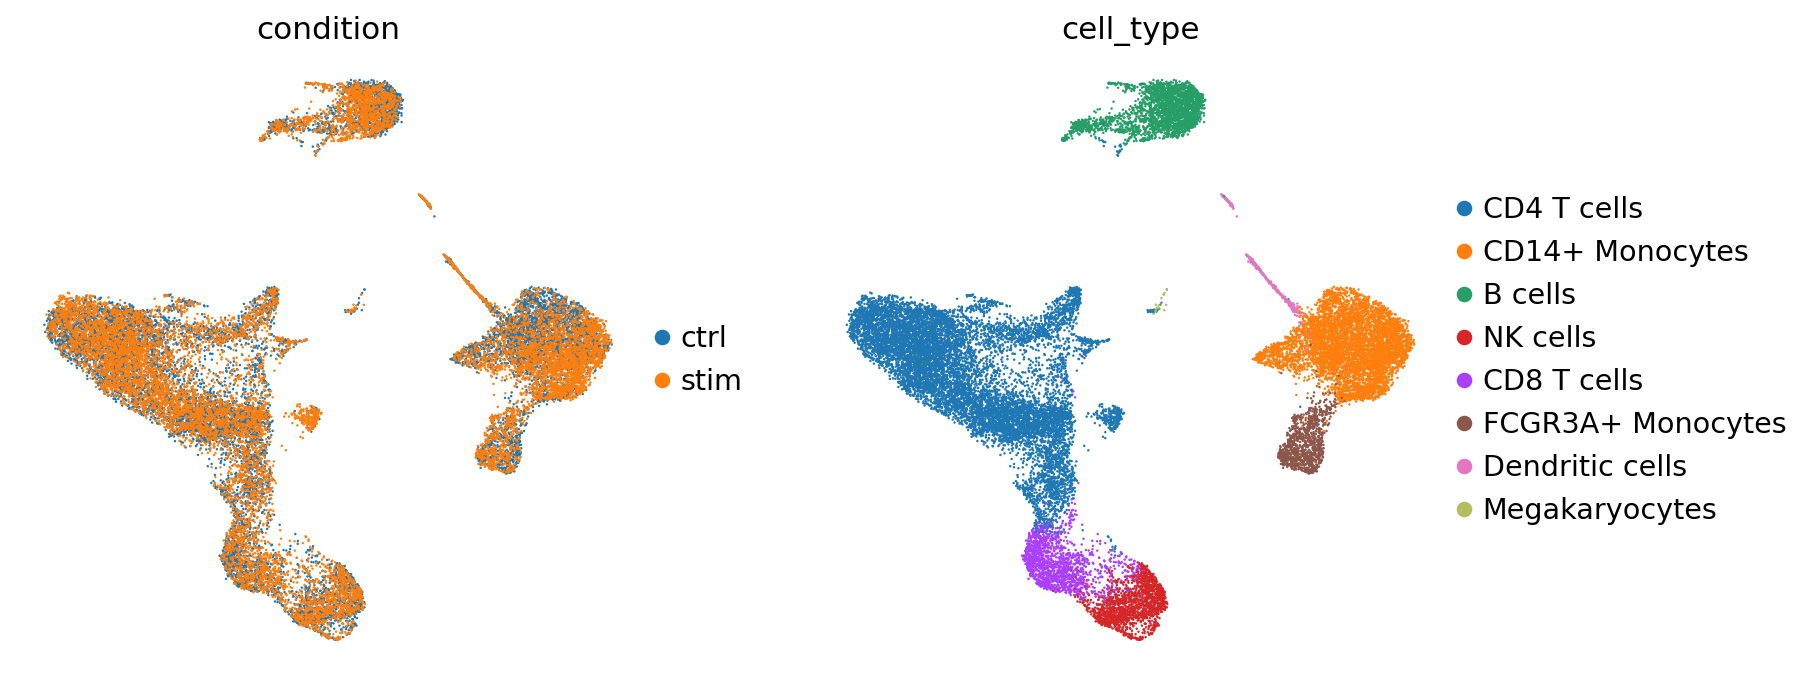

In [15]:
sc.pl.umap(adata, color=["condition", "cell_type"], frameon=False)

In [16]:
# ── Unique values ─────────────────────────────────────────────
for col in ["condition", "cluster", "cell_type", "patient"]:
    print(f"\n{col}: {adata.obs[col].unique().tolist()}")

# ── Cells per condition ───────────────────────────────────────
print("\n===== Cells per condition =====")
print(adata.obs["condition"].value_counts())

# ── Patients per condition ────────────────────────────────────
print("\n===== Patients per condition =====")
print(adata.obs.groupby("condition")["patient"].nunique())

# ── Cells per patient per condition ──────────────────────────
print("\n===== Cells per patient per condition =====")
print(adata.obs.groupby(["condition", "patient"]).size().reset_index(name="n_cells"))


condition: ['ctrl', 'stim']

cluster: [9, 3, 4, 5, 7, 10, 1, 2, 6, 8]

cell_type: ['CD14+ Monocytes', 'CD4 T cells', 'Dendritic cells', 'NK cells', 'CD8 T cells', 'B cells', 'FCGR3A+ Monocytes', 'Megakaryocytes']

patient: ['patient_1016', 'patient_1256', 'patient_1488', 'patient_1039', 'patient_1015', 'patient_107', 'patient_1244', 'patient_101']

===== Cells per condition =====
condition
stim    12301
ctrl    12261
Name: count, dtype: int64

===== Patients per condition =====
condition
ctrl    8
stim    8
Name: patient, dtype: int64

===== Cells per patient per condition =====
   condition       patient  n_cells
0       ctrl   patient_101      858
1       ctrl   patient_107      517
2       ctrl  patient_1015     2738
3       ctrl  patient_1016     1723
4       ctrl  patient_1039      408
5       ctrl  patient_1244     1879
6       ctrl  patient_1256     2108
7       ctrl  patient_1488     2030
8       stim   patient_101     1166
9       stim   patient_107      525
10      stim  pat

/tmp/ipykernel_70033/725113173.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_70033/725113173.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [17]:
# ── Cells per cell_type per patient ──────────────────────────
print("\n===== Cells per cell_type x patient =====")
tbl = (adata.obs
       .groupby(["cell_type", "patient"])
       .size()
       .reset_index(name="n_cells")
       .pivot(index="cell_type", columns="patient", values="n_cells")
       .fillna(0)
       .astype(int))
tbl["TOTAL"] = tbl.sum(axis=1)
tbl = tbl.sort_values("TOTAL", ascending=False)
print(tbl.to_string())

# ── Also per condition ────────────────────────────────────────
print("\n===== Cells per cell_type x condition =====")
tbl2 = (adata.obs
        .groupby(["cell_type", "condition"])
        .size()
        .reset_index(name="n_cells")
        .pivot(index="cell_type", columns="condition", values="n_cells")
        .fillna(0)
        .astype(int))
tbl2["TOTAL"] = tbl2.sum(axis=1)
tbl2 = tbl2.sort_values("TOTAL", ascending=False)
print(tbl2.to_string())

# ── All three together ────────────────────────────────────────
print("\n===== Cells per cell_type x patient x condition =====")
tbl3 = (adata.obs
        .groupby(["cell_type", "patient", "condition"])
        .size()
        .reset_index(name="n_cells"))
print(tbl3.to_string())


===== Cells per cell_type x patient =====
patient            patient_101  patient_107  patient_1015  patient_1016  patient_1039  patient_1244  patient_1256  patient_1488  TOTAL
cell_type                                                                                                                             
CD4 T cells                820          379          1786           963           503          2000          2042          2745  11238
CD14+ Monocytes            476          389          1577           748           290           718           789           709   5696
B cells                    247          104           825           248            67           214           437           509   2651
NK cells                   149           77           354           188            43           209           428           268   1716
CD8 T cells                 83           18           145           993            20            41           246            75   1621
FCGR3A+ Mono

/tmp/ipykernel_70033/1799865309.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_70033/1799865309.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_70033/1799865309.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [18]:
print("LIGAND RECEPTOR inference :")

LIGAND RECEPTOR inference :


In [19]:
adata_stim = adata[adata.obs["condition"] == "stim"].copy()
adata_stim

AnnData object with n_obs × n_vars = 12301 × 15701
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'condition', 'cluster', 'cell_type', 'patient', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'n_genes', 'sample'
    var: 'name', 'n_cells'
    uns: 'log1p', 'condition_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

In [20]:
cellphonedb(
    adata_stim, 
    groupby = "cell_type", 
    use_raw = False, 
    return_all_lrs = True, 
    verbose = True
)

2026-03-27 12:32:29 | [INFO] Using resource `consensus`.
2026-03-27 12:32:29 | [INFO] Using `.X`!
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2026-03-27 12:32:29 | [WARNING] 227 features of mat are empty, they will be removed.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
2026-03-27 12:32:30 | [INFO] 0.46 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 12301 samples and 892 features


/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/hom

In [21]:
adata_stim.uns["liana_res"].head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lrs_to_keep,lr_means,cellphone_pvals
42936,B2M,B2M,4.431647,1.0,KLRD1,KLRD1,0.591819,0.537747,CD8 T cells,NK cells,True,2.511733,0.0
41412,B2M,B2M,4.359549,1.0,KLRD1,KLRD1,0.591819,0.537747,NK cells,NK cells,True,2.475684,0.0
55128,B2M,B2M,4.431647,1.0,KLRD1,KLRD1,0.419571,0.406173,CD8 T cells,CD8 T cells,True,2.425609,0.0
53604,B2M,B2M,4.359549,1.0,KLRD1,KLRD1,0.419571,0.406173,NK cells,CD8 T cells,True,2.389560,0.0
42931,B2M,B2M,4.431647,1.0,KLRC1,KLRC1,0.274590,0.271777,CD8 T cells,NK cells,True,2.353119,0.0


In [22]:
li.rs.show_resources()

['baccin2019',
 'cellcall',
 'cellchatdb',
 'cellinker',
 'cellphonedb',
 'celltalkdb',
 'connectomedb2020',
 'consensus',
 'embrace',
 'guide2pharma',
 'hpmr',
 'icellnet',
 'italk',
 'kirouac2010',
 'lrdb',
 'mouseconsensus',
 'ramilowski2015']

In [23]:
# Option 1 — help
# help(cellphonedb)

# Option 2 — signature only
# import inspect
# print(inspect.signature(cellphonedb))

print('''

| Parameter        |       Default | Description                                                                    |
| ---------------- | ------------: | ------------------------------------------------------------------------------ |
| `adata`          |      required | AnnData object                                                                 |
| `groupby`        |      required | Column in `adata.obs` containing cell type labels, for example `"subcelltype"` |
| `resource_name`  | `"consensus"` | Ligand–receptor database to use                                                |
| `expr_prop`      |         `0.1` | Minimum proportion of cells expressing a gene                                  |
| `min_cells`      |           `5` | Minimum number of cells required per cell type                                 |
| `use_raw`        |        `True` | Whether to use `adata.raw`                                                     |
| `layer`          |        `None` | Layer to use, for example `"counts"`                                           |
| `return_all_lrs` |       `False` | Whether to return all ligand–receptor pairs or only significant ones           |
| `n_perms`        |        `1000` | Number of permutations                                                         |
| `seed`           |          `42` | Random seed                                                                    |
| `verbose`        |       `False` | Whether to print progress                                                      |
| `inplace`        |        `True` | Save results to `adata.uns["liana_res"]`                                       |

''')




| Parameter        |       Default | Description                                                                    |
| ---------------- | ------------: | ------------------------------------------------------------------------------ |
| `adata`          |      required | AnnData object                                                                 |
| `groupby`        |      required | Column in `adata.obs` containing cell type labels, for example `"subcelltype"` |
| `resource_name`  | `"consensus"` | Ligand–receptor database to use                                                |
| `expr_prop`      |         `0.1` | Minimum proportion of cells expressing a gene                                  |
| `min_cells`      |           `5` | Minimum number of cells required per cell type                                 |
| `use_raw`        |        `True` | Whether to use `adata.raw`                                                     |
| `layer`          |        `None` | Layer to use, for

In [24]:
# cellphonedb?

In [25]:
# By default, in CellPhoneDB and LIANA, any interactions in which either entity is not expressed in 
# above 10% of cells per cell type is considered as a false positive, under the assumption that 
# since CCC occurs between cell types, a sufficient proportion of cells within should express the genes.

# *_means: entity expression mean per cell type
# lr_means: mean ligand-receptor expression, as a measure of ligand-receptor interaction magnitude
# cellphone_pvals: permutation-based p-values, as a measure of interaction specificity

In [26]:
# typically most methods use a pair of SCORING FUNCTIONS - 
# where one often corresponds to the MAGNITUDE (strength) of interaction and 
# the other reflects the SPECIFICITY (specificity) of a given interaction to a pair of cell identities.

In [27]:
print("Visual Exploration")

Visual Exploration


/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


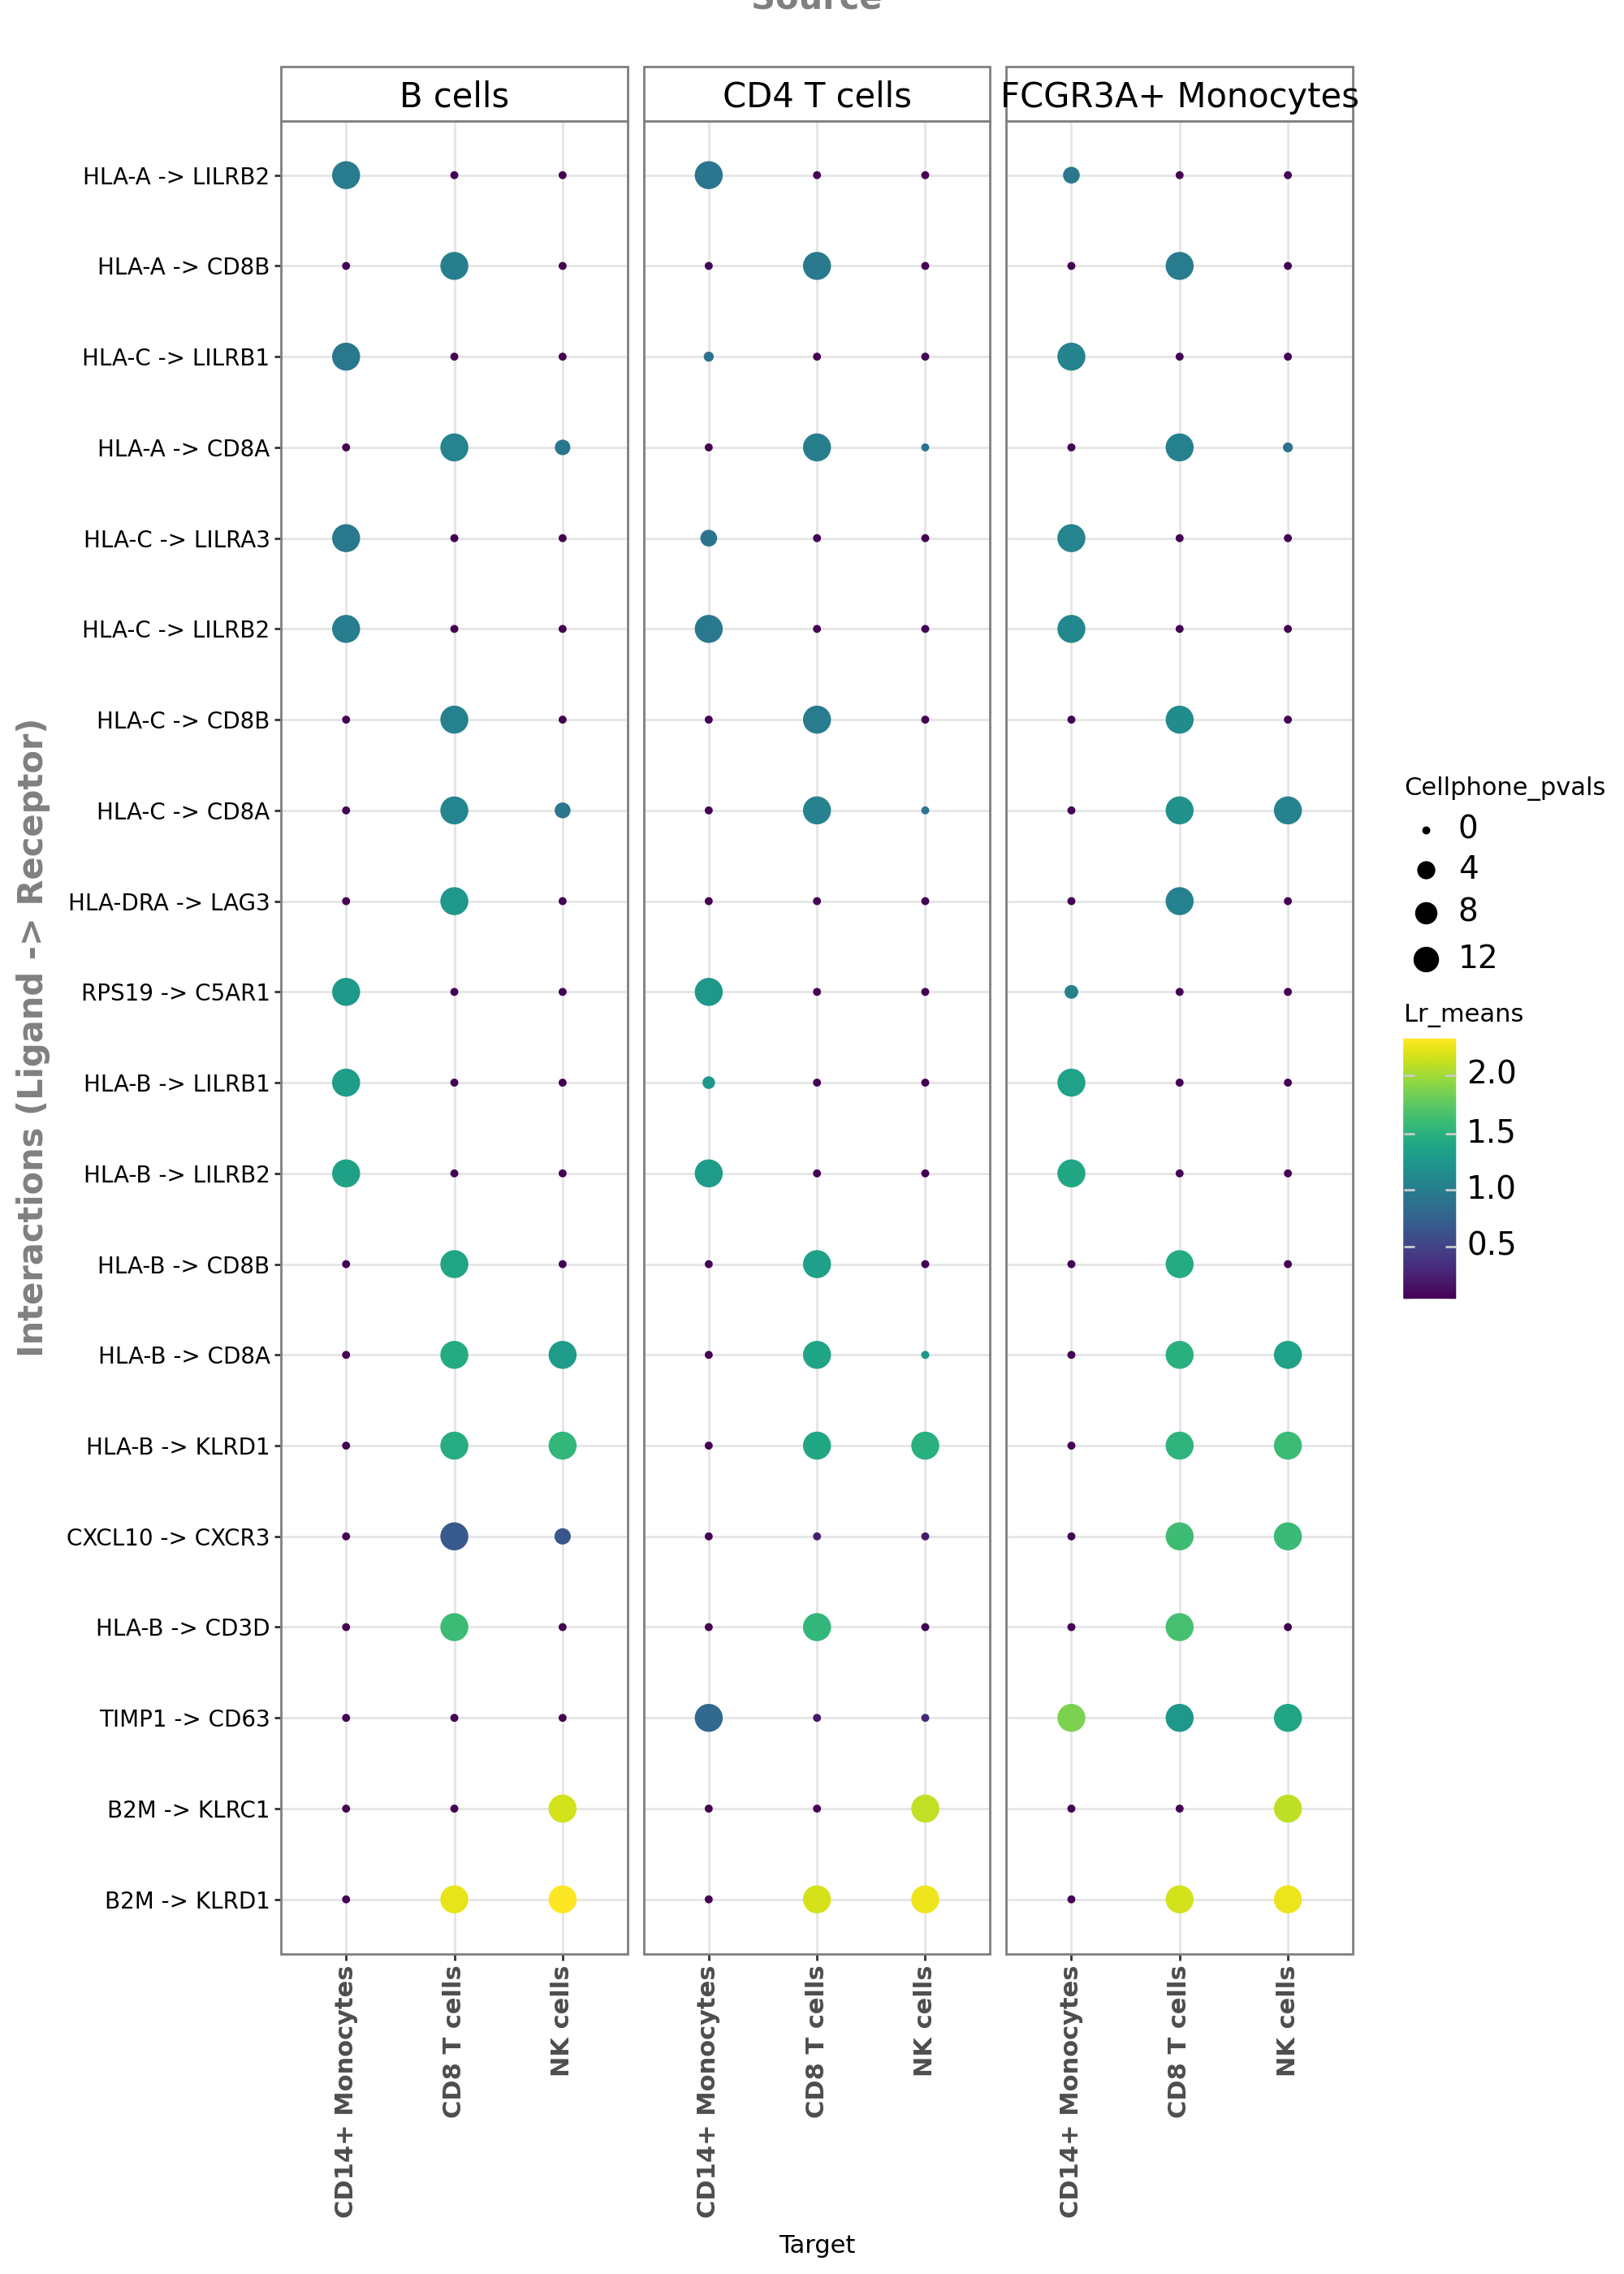

In [28]:
li.pl.dotplot(
    adata = adata_stim,
    colour = "lr_means",
    size = "cellphone_pvals",
    inverse_size = True,
    source_labels = ["CD4 T cells", "B cells", "FCGR3A+ Monocytes"],
    target_labels = ["CD8 T cells", "CD14+ Monocytes", "NK cells"],
    orderby="lr_means",
    orderby_ascending=False,
    top_n=20,
    figure_size=(10, 14),
    size_range=(1, 6),
)

In [29]:
print("Generating a Ligand-Receptor consensus with LIANA")

Generating a Ligand-Receptor consensus with LIANA


In [30]:
# One could also use multiple methods and focus on their consensus, 
# or in other words focus on interactions consistently predicted as relevant. 

# To this end, we will run the rank_aggregate method of liana [Dimitrov et al., 2022], 
# which generates a probability distribution of highly ranked interactions across the methods.

In [31]:
li.method.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [32]:
from liana.method import rank_aggregate

In [33]:
rank_aggregate(
    adata_stim, 
    groupby ="cell_type", 
    return_all_lrs = True, 
    use_raw = False, 
    verbose = True
)

2026-03-27 12:32:34 | [INFO] Using resource `consensus`.
2026-03-27 12:32:34 | [INFO] Using `.X`!
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2026-03-27 12:32:34 | [WARNING] 227 features of mat are empty, they will be removed.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
2026-03-27 12:32:35 | [INFO] 0.46 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 12301 samples and 892 features


/home/tanasa/anaconda3/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/hom

...

/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/hom

Running NATMI


/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/hom

Running SingleCellSignalR


/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/hom

In [34]:
adata_stim.uns["liana_res"].drop_duplicates(
    ["ligand_complex", 
     "receptor_complex"]
).head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
47366,CD8 T cells,NK cells,B2M,KLRD1,2.511733,0.0,2.622731,1.541761,0.858931,0.080626,0.980689,5.876239e-08,3.271001e-08
63853,FCGR3A+ Monocytes,CD14+ Monocytes,TIMP1,CD63,1.877567,0.0,3.374182,1.478816,1.808744,0.123245,0.982935,5.876239e-08,1.758624e-06
90619,NK cells,CD8 T cells,HLA-B,CD3D,1.861224,0.0,2.098889,0.968749,0.786989,0.069319,0.978462,5.876239e-08,1.922106e-06
96721,NK cells,NK cells,HLA-B,KLRD1,1.810745,0.0,1.793015,1.439987,0.955190,0.089589,0.976738,5.876239e-08,2.092852e-06
54077,Dendritic cells,CD8 T cells,HLA-DRA,LAG3,1.712091,0.0,1.831722,2.041237,1.892298,0.241036,0.976980,1.721140e-08,3.055504e-06


In [35]:
# The magnitude_rank and specificity_rank for each interaction, 
# which represent the consensus interaction MAGNITUDE (strength of expression) 
# and SPECIFICITY (across all cell type pairs), respectively. 

# For example, going back to CellPhoneDB, lr_mean and cellphone_pvals will be correspondingly aggregated into those.

In [36]:
print('''
| Column           | Method             | Interpretation                                                          |
| ---------------- | ------------------ | ----------------------------------------------------------------------- |
| `lr_means`       | CellPhoneDB        | Mean expression of ligand and receptor — higher = stronger interaction  |
| `expr_prod`      | NATMI / Connectome | Product of ligand × receptor expression — higher = stronger interaction |
| `lrscore`        | SingleCellSignalR  | Interaction score (0–1) — higher = stronger interaction                 |
| `magnitude_rank` | Consensus          | Aggregated rank — lower = stronger interaction                          |
''')


| Column           | Method             | Interpretation                                                          |
| ---------------- | ------------------ | ----------------------------------------------------------------------- |
| `lr_means`       | CellPhoneDB        | Mean expression of ligand and receptor — higher = stronger interaction  |
| `expr_prod`      | NATMI / Connectome | Product of ligand × receptor expression — higher = stronger interaction |
| `lrscore`        | SingleCellSignalR  | Interaction score (0–1) — higher = stronger interaction                 |
| `magnitude_rank` | Consensus          | Aggregated rank — lower = stronger interaction                          |



In [37]:
print('''
| Column             | Method      | Interpretation                                          |
| ------------------ | ----------- | ------------------------------------------------------- |
| `cellphone_pvals`  | CellPhoneDB | Permutation p-value — lower = more specific interaction |
| `scaled_weight`    | Connectome  | Specificity weight — higher = more specific interaction |
| `spec_weight`      | NATMI       | Specificity score — higher = more specific interaction  |
| `lr_logfc`         | log2FC      | Log fold change — higher = more specific interaction    |
| `specificity_rank` | Consensus   | Aggregated rank — lower = more specific interaction     |
''')


| Column             | Method      | Interpretation                                          |
| ------------------ | ----------- | ------------------------------------------------------- |
| `cellphone_pvals`  | CellPhoneDB | Permutation p-value — lower = more specific interaction |
| `scaled_weight`    | Connectome  | Specificity weight — higher = more specific interaction |
| `spec_weight`      | NATMI       | Specificity score — higher = more specific interaction  |
| `lr_logfc`         | log2FC      | Log fold change — higher = more specific interaction    |
| `specificity_rank` | Consensus   | Aggregated rank — lower = more specific interaction     |



/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


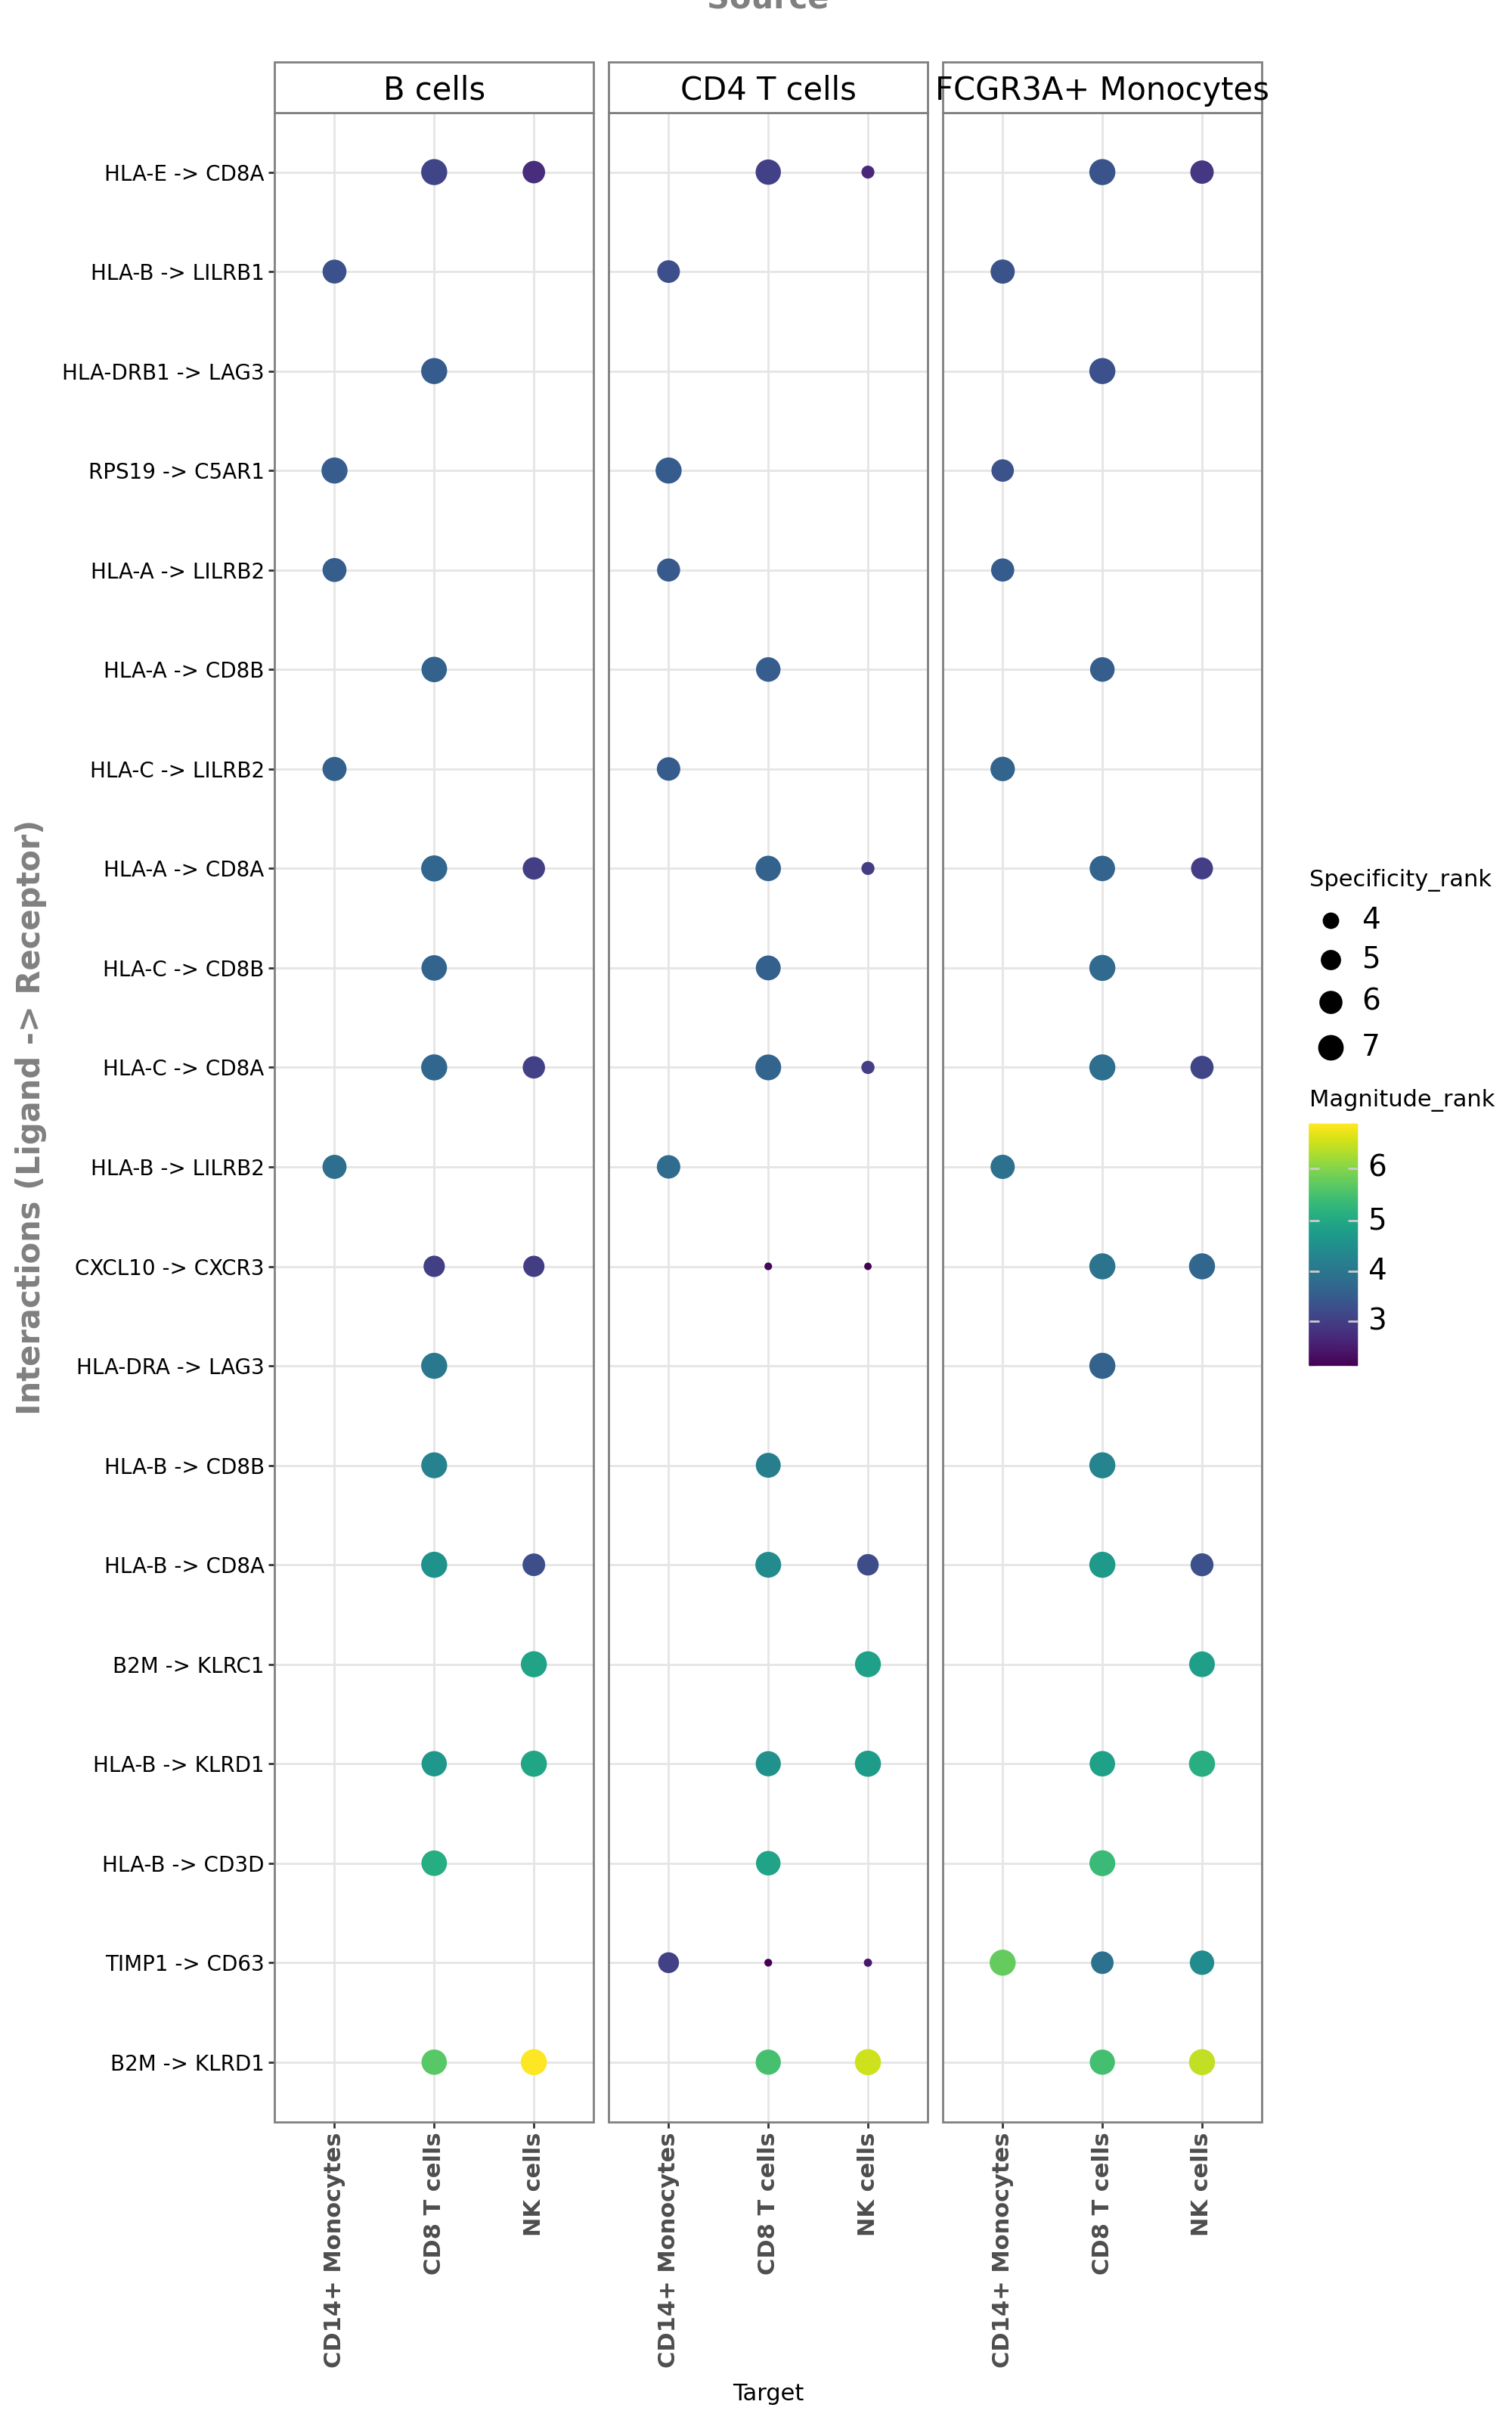

In [38]:
# ── Filter manually then plot ─────────────────────────────────
liana_res = adata_stim.uns["liana_res"].copy()

# fix warning — use .loc
liana_filtered = liana_res.loc[liana_res["specificity_rank"] <= 0.05].copy()
adata_stim.uns["liana_res"] = liana_filtered

# ── Plot ──────────────────────────────────────────────────────
li.pl.dotplot(
    adata             = adata_stim,
    colour            = "magnitude_rank",
    size              = "specificity_rank",
    inverse_colour    = True,
    inverse_size      = True,
    source_labels     = ["CD4 T cells", "B cells", "FCGR3A+ Monocytes"],
    target_labels     = ["CD8 T cells", "CD14+ Monocytes", "NK cells"],
    orderby           = "magnitude_rank",
    orderby_ascending = True,
    top_n             = 20,
    figure_size       = (10, 16),
    size_range        = (1, 6),
)

# ── Restore original results ──────────────────────────────────
# adata_stim.uns["liana_res"] = liana_res